# Laboratorio 2 — Exploración de series con catch22
### CC3084 Data Science · UVG · Semestre II 2026

**Ejercicio 2, incisos 2.1–2.13.** En este notebook se comparan las siete series de ingreso de viajeros mediante características de catch22. El objetivo no es pronosticar, sino encontrar similitudes y diferencias en su dinámica sin que el volumen de viajeros domine la comparación.

## 2.1 ¿Qué es catch22?

**catch22** (*CAnonical Time-series CHaracteristics*) resume una serie en 22 características seleccionadas de la biblioteca hctsa. Estas variables fueron elegidas porque son poco redundantes, rápidas de calcular y mantienen buen poder para discriminar tipos de series. Describen propiedades como distribución, autocorrelación, periodicidad, entropía o predictibilidad, cambios de régimen y escalamiento de las fluctuaciones.

Esto permite convertir series con longitudes y magnitudes distintas en vectores comparables. En este trabajo se z-normaliza **cada serie por separado antes de catch22**, para concentrarnos en su forma y dinámica, no en cuál vía o país recibe más viajeros. Luego se estandariza **cada característica entre las siete series** antes de PCA, clustering y distancias. Son dos pasos diferentes y ambos son necesarios.

In [1]:
# Si hace falta instalar catch22 en el kernel, descomentar la siguiente línea:
# %pip install pycatch22

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycatch22
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="colorblind")

# Permite ejecutar el notebook desde la raíz o desde notebooks/.
raiz = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "series.py").exists())
sys.path.insert(0, str(raiz))
from src.series import META, construir_series

series = construir_series()
resumen = pd.DataFrame({
    "categoría": {nombre: META[nombre]["categoria"] for nombre in series},
    "meses": {nombre: len(s) for nombre, s in series.items()},
    "inicio": {nombre: s.index.min().date() for nombre, s in series.items()},
    "fin": {nombre: s.index.max().date() for nombre, s in series.items()},
    "ceros": {nombre: int((s == 0).sum()) for nombre, s in series.items()},
})
resumen

,categoría,meses,inicio,fin,ceros
Total,Total,210,2009-01-01,2026-06-01,0
Aérea,Vía,210,2009-01-01,2026-06-01,0
Terrestre,Vía,210,2009-01-01,2026-06-01,0
Marítima,Vía,168,2009-01-01,2022-12-01,45
El Salvador,País,210,2009-01-01,2026-06-01,5
Estados Unidos,País,210,2009-01-01,2026-06-01,5
Honduras,País,210,2009-01-01,2026-06-01,5


La serie Marítima requiere cuidado: solo llega hasta diciembre de 2022 y contiene muchos ceros por la temporada baja de cruceros y el cierre pandémico. catch22 acepta su longitud de 168 meses, así que no se rellena ni se recorta artificialmente; esta diferencia se toma como una limitación al interpretar su separación.

## 2.2–2.4 Extracción y matriz de características

catch22 se aplica una vez sobre cada serie completa. Los posibles valores no finitos se sustituyen por cero para evitar que una característica indefinida detenga el análisis. Se construye la matriz solicitada de 7 filas × 22 columnas y después `StandardScaler` estandariza cada columna entre las siete observaciones.

In [2]:
def extraer_catch22(serie):
    """Z-normaliza una serie completa y devuelve sus 22 características."""
    x = serie.to_numpy(dtype=float)
    x_z = (x - x.mean()) / (x.std() + 1e-9)
    resultado = pycatch22.catch22_all(x_z.tolist())
    valores = np.nan_to_num(
        np.asarray(resultado["values"], dtype=float),
        nan=0.0, posinf=0.0, neginf=0.0
    )
    return resultado["names"], valores

filas = []
for nombre, serie in series.items():
    nombres_c22, valores = extraer_catch22(serie)
    filas.append(valores)

matriz_c22 = pd.DataFrame(filas, index=series.keys(), columns=nombres_c22)
assert matriz_c22.shape == (7, 22)
assert np.isfinite(matriz_c22.to_numpy()).all()

escalador = StandardScaler()
matriz_z = pd.DataFrame(
    escalador.fit_transform(matriz_c22),
    index=matriz_c22.index,
    columns=matriz_c22.columns,
)
print(f"Dimensión de la matriz: {matriz_c22.shape}")
display(matriz_c22.round(3))

Dimensión de la matriz: (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.083,0.342,8.965,3.0,0.352,-0.062,0.933,30.0,0.014,11.0,...,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
Aérea,-0.398,-0.115,6.591,10.0,0.206,-0.163,0.957,34.0,0.010,11.0,...,0.071,0.186,0.324,0.758,5.0,2.001,0.857,0.857,0.172,0.739
Terrestre,0.277,-0.193,9.573,2.0,0.484,-0.025,0.933,29.0,0.014,3.0,...,0.056,0.219,0.329,0.818,6.0,1.782,0.833,0.857,0.098,0.616
Marítima,-0.530,-0.745,1.928,6.0,0.112,-0.073,0.820,9.0,0.006,11.0,...,0.200,0.298,0.363,0.711,5.0,2.022,0.146,0.732,0.515,0.940
El Salvador,-0.252,-0.495,13.998,2.0,0.346,-0.010,0.890,31.0,0.021,3.0,...,0.038,0.767,0.310,0.848,5.0,1.803,0.143,0.857,0.074,0.537
Estados Unidos,-0.618,-0.361,9.265,2.0,0.256,0.020,0.909,12.0,0.021,5.0,...,0.038,0.829,0.324,0.724,5.0,1.981,0.167,0.738,0.098,0.737
Honduras,-0.177,-0.395,18.242,8.0,0.453,-0.093,0.871,39.0,0.056,8.0,...,0.029,0.752,0.319,0.866,5.0,1.797,0.857,0.738,0.049,0.474


In [3]:
# Comprobación de la estandarización por característica.
comprobacion = pd.DataFrame({
    "media": matriz_z.mean(),
    "desviación (ddof=0)": matriz_z.std(ddof=0),
})
display(comprobacion.round(6))

,media,desviación (ddof=0)
DN_HistogramMode_5,-0.0,1.0
DN_HistogramMode_10,0.0,1.0
CO_f1ecac,-0.0,1.0
CO_FirstMin_ac,-0.0,1.0
CO_HistogramAMI_even_2_5,-0.0,1.0
CO_trev_1_num,0.0,1.0
MD_hrv_classic_pnn40,-0.0,1.0
SB_BinaryStats_mean_longstretch1,0.0,1.0
SB_TransitionMatrix_3ac_sumdiagcov,-0.0,1.0
PD_PeriodicityWang_th0_01,-0.0,1.0


## 2.5 Exploración de la matriz

### Heatmap de las 22 características
Los colores muestran cuántas desviaciones estándar se aleja cada serie del promedio de las siete. Por eso se pueden comparar columnas aunque sus unidades originales sean distintas.

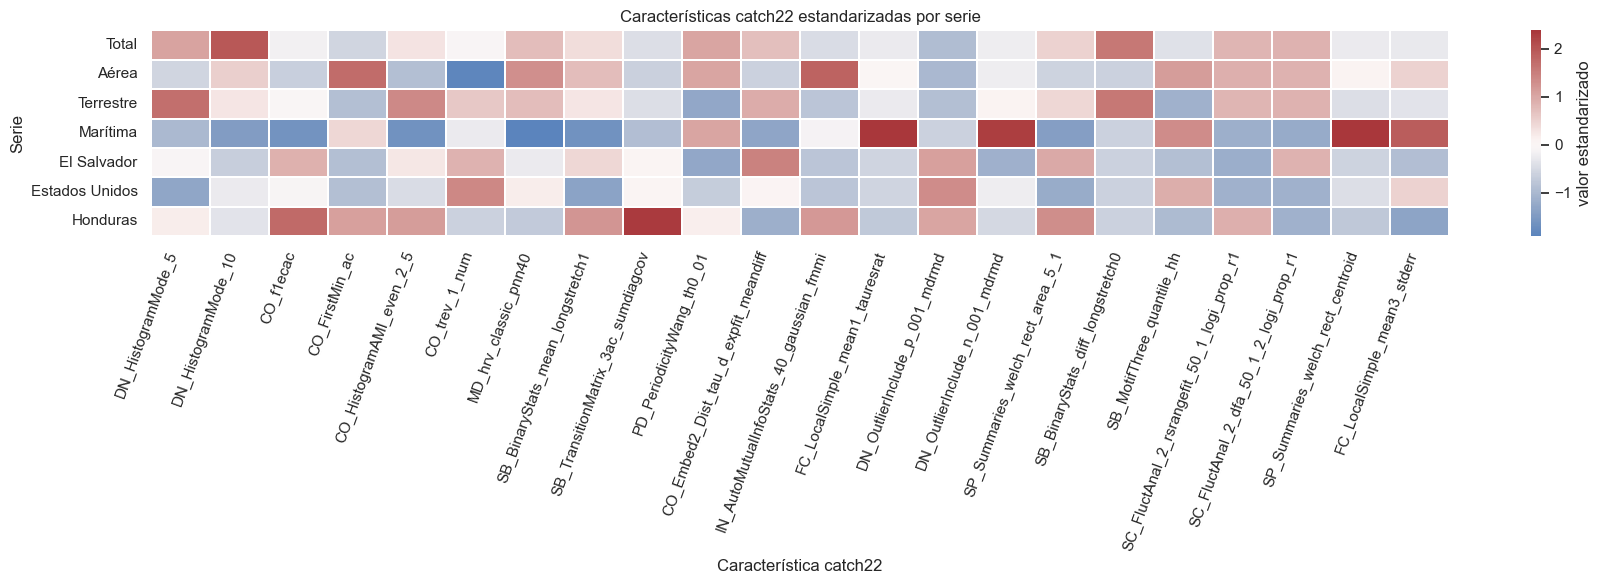

In [4]:
plt.figure(figsize=(18, 6))
sns.heatmap(matriz_z, cmap="vlag", center=0, linewidths=0.3,
            cbar_kws={"label": "valor estandarizado"})
plt.title("Características catch22 estandarizadas por serie")
plt.xlabel("Característica catch22")
plt.ylabel("Serie")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

### PCA: resumen de la separación
PCA crea combinaciones de las 22 variables. Se muestran tres componentes para cuantificar la información retenida y se grafica PC1 contra PC2, coloreando por categoría original. Las cargas absolutas más grandes indican qué características influyeron más en cada eje.

,Varianza explicada (%)
PC1,44.54
PC2,21.83
PC3,19.25


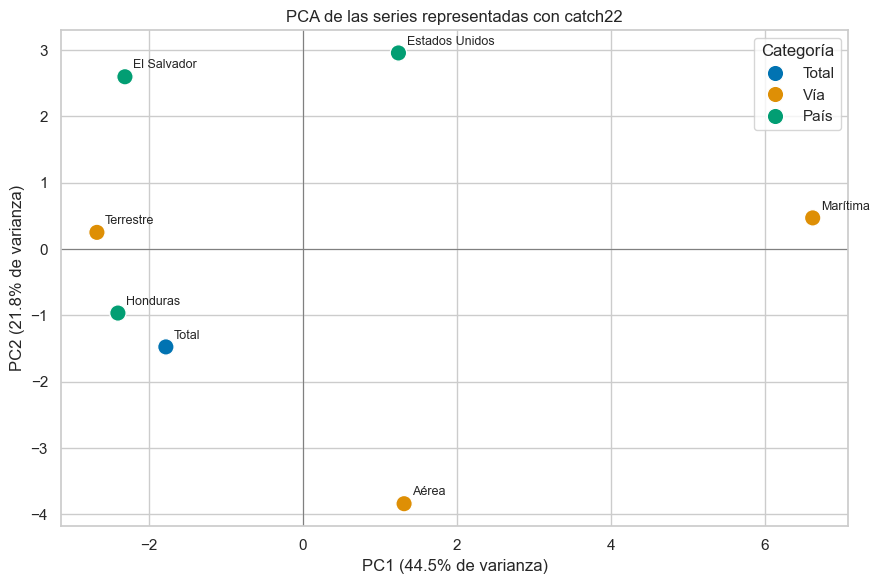

,PC1,PC2,PC3,Categoría
Total,-1.781,-1.475,-2.438,Total
Aérea,1.314,-3.839,0.270,Vía
Terrestre,-2.677,0.252,-2.524,Vía
Marítima,6.622,0.470,-0.186,Vía
El Salvador,-2.313,2.598,0.361,País
Estados Unidos,1.240,2.957,0.404,País
Honduras,-2.404,-0.964,4.114,País


In [5]:
pca = PCA(n_components=3, random_state=42)
coordenadas = pca.fit_transform(matriz_z)
scores = pd.DataFrame(coordenadas, index=matriz_z.index,
                      columns=["PC1", "PC2", "PC3"])
scores["Categoría"] = [META[n]["categoria"] for n in scores.index]

varianza = pd.Series(
    pca.explained_variance_ratio_ * 100,
    index=["PC1", "PC2", "PC3"],
    name="Varianza explicada (%)"
)
display(varianza.round(2).to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=scores, x="PC1", y="PC2", hue="Categoría",
                s=140, ax=ax)
for nombre, fila in scores.iterrows():
    ax.annotate(nombre, (fila["PC1"], fila["PC2"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel(f"PC1 ({varianza['PC1']:.1f}% de varianza)")
ax.set_ylabel(f"PC2 ({varianza['PC2']:.1f}% de varianza)")
ax.set_title("PCA de las series representadas con catch22")
plt.tight_layout()
plt.show()
display(scores.round(3))

In [6]:
cargas = pd.DataFrame(
    pca.components_.T, index=matriz_z.columns,
    columns=["PC1", "PC2", "PC3"]
)
for componente in ["PC1", "PC2"]:
    print(f"Características con mayor carga absoluta en {componente}:")
    importantes = cargas[componente].reindex(
        cargas[componente].abs().sort_values(ascending=False).head(8).index
    )
    display(importantes.round(3).to_frame("carga"))

Características con mayor carga absoluta en PC1:


,carga
FC_LocalSimple_mean3_stderr,0.302
CO_HistogramAMI_even_2_5,-0.294
SP_Summaries_welch_rect_centroid,0.293
SB_MotifThree_quantile_hh,0.285
FC_LocalSimple_mean1_tauresrat,0.282
SP_Summaries_welch_rect_area_5_1,-0.281
DN_OutlierInclude_n_001_mdrmd,0.273
CO_f1ecac,-0.257


Características con mayor carga absoluta en PC2:


,carga
CO_trev_1_num,0.424
IN_AutoMutualInfoStats_40_gaussian_fmmi,-0.365
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,-0.364
CO_FirstMin_ac,-0.351
PD_PeriodicityWang_th0_01,-0.324
DN_OutlierInclude_p_001_mdrmd,0.310
SB_BinaryStats_mean_longstretch1,-0.241
DN_HistogramMode_10,-0.228


### Clustering jerárquico y K-Means
Con solo siete observaciones, el dendrograma conserva más información que obligar una partición. Se usa enlace Ward sobre distancias euclidianas. Como comprobación adicional se muestran tres grupos de K-Means; no se interpretan como categorías definitivas.

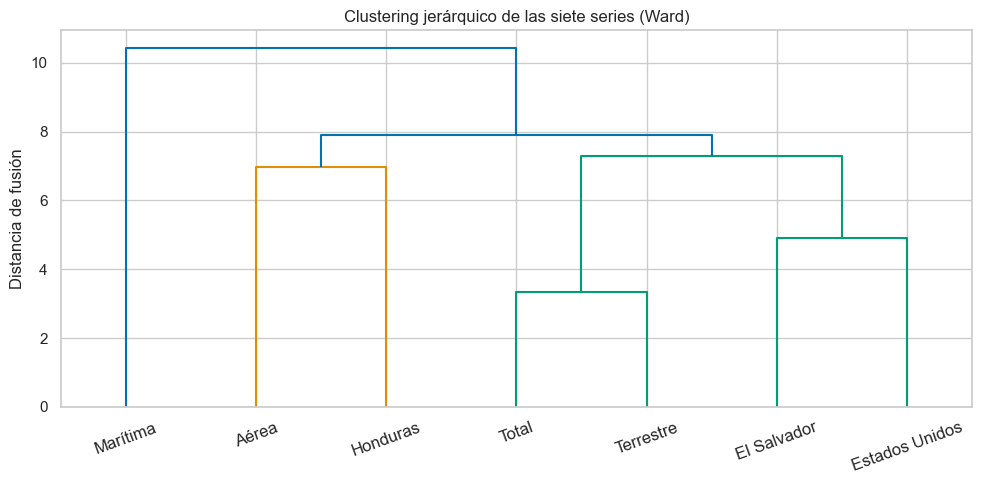

,categoría original,grupo jerárquico,grupo K-Means
Total,Total,2,3
Aérea,Vía,1,3
Terrestre,Vía,2,3
Marítima,Vía,3,2
El Salvador,País,2,1
Estados Unidos,País,2,1
Honduras,País,1,1


In [7]:
enlace = linkage(matriz_z, method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(enlace, labels=matriz_z.index.tolist(), leaf_rotation=20, ax=ax)
ax.set_title("Clustering jerárquico de las siete series (Ward)")
ax.set_ylabel("Distancia de fusión")
plt.tight_layout()
plt.show()

grupos_jerarquicos = fcluster(enlace, t=3, criterion="maxclust")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
comparacion_grupos = pd.DataFrame({
    "categoría original": [META[n]["categoria"] for n in matriz_z.index],
    "grupo jerárquico": grupos_jerarquicos,
    "grupo K-Means": kmeans.fit_predict(matriz_z) + 1,
}, index=matriz_z.index)
display(comparacion_grupos)

### Correlaciones entre características
Esta matriz sirve para detectar redundancia dentro de nuestra muestra. Debe leerse con cautela: cada correlación usa apenas siete series, de modo que una relación alta es descriptiva y no una prueba general sobre catch22.

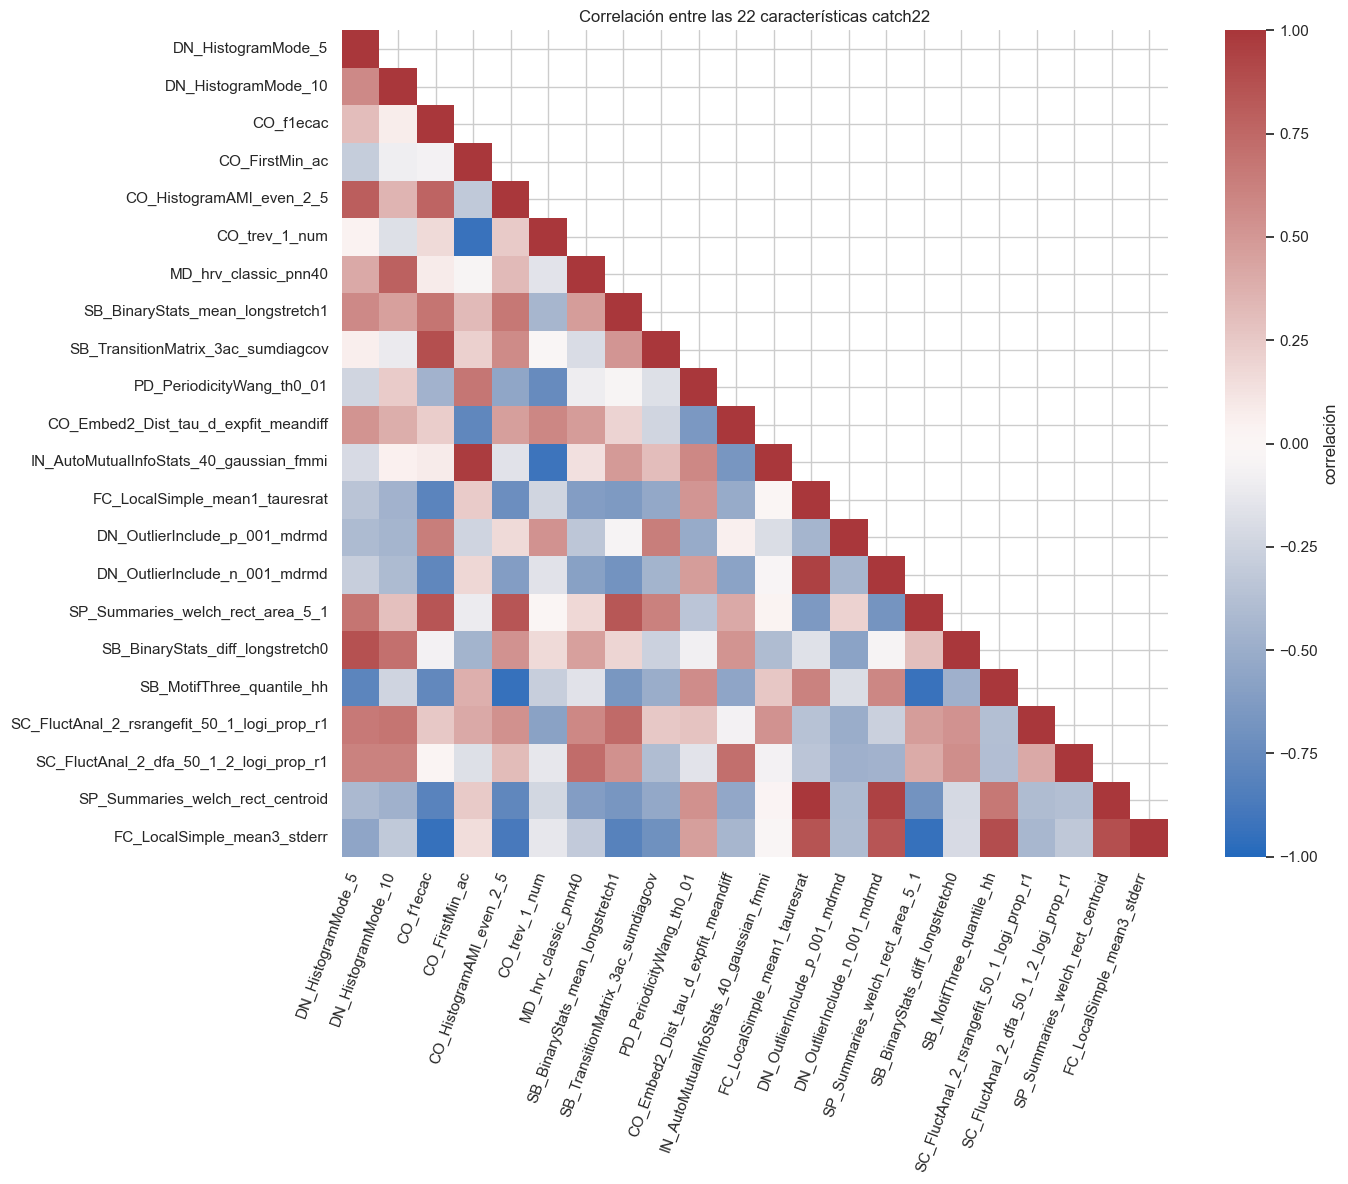

,level_0,level_1,correlación,|correlación|
284,FC_LocalSimple_mean1_tauresrat,SP_Summaries_welch_rect_centroid,0.996,0.996
77,CO_FirstMin_ac,IN_AutoMutualInfoStats_40_gaussian_fmmi,0.974,0.974
278,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_n_001_mdrmd,0.952,0.952
328,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_centroid,0.947,0.947
65,CO_f1ecac,FC_LocalSimple_mean3_stderr,-0.944,0.944
351,SP_Summaries_welch_rect_area_5_1,FC_LocalSimple_mean3_stderr,-0.942,0.942
105,CO_HistogramAMI_even_2_5,SB_MotifThree_quantile_hh,-0.939,0.939
347,SP_Summaries_welch_rect_area_5_1,SB_MotifThree_quantile_hh,-0.933,0.933
71,CO_FirstMin_ac,CO_trev_1_num,-0.931,0.931
121,CO_trev_1_num,IN_AutoMutualInfoStats_40_gaussian_fmmi,-0.917,0.917


In [8]:
correlaciones = matriz_c22.corr()
mascara = np.triu(np.ones_like(correlaciones, dtype=bool), k=1)
plt.figure(figsize=(15, 12))
sns.heatmap(correlaciones, mask=mascara, cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "correlación"})
plt.title("Correlación entre las 22 características catch22")
plt.xticks(rotation=70, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pares_corr = (correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool))
              .stack().rename("correlación").reset_index())
pares_corr["|correlación|"] = pares_corr["correlación"].abs()
display(pares_corr.nlargest(10, "|correlación|").round(3))

### Mapa de distancias entre series
La distancia euclidiana se calcula sobre las 22 características estandarizadas. Un valor pequeño indica perfiles catch22 parecidos; la diagonal es cero porque compara cada serie consigo misma.

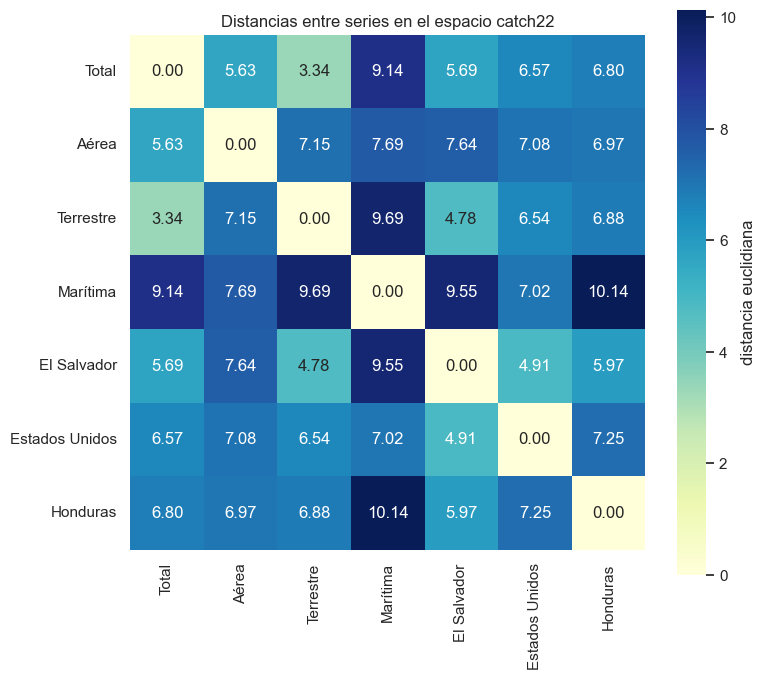

Pares más cercanos:


distancia
Total       Terrestre           3.336
Terrestre   El Salvador         4.779
El Salvador Estados Unidos      4.909
Total       Aérea               5.633
            El Salvador         5.694
El Salvador Honduras            5.969
Terrestre   Estados Unidos      6.540

Distancia promedio de cada serie respecto a las demás:


,distancia promedio
Marítima,8.872
Honduras,7.334
Aérea,7.026
Estados Unidos,6.561
El Salvador,6.423
Terrestre,6.396
Total,6.197


In [9]:
distancias = pd.DataFrame(
    squareform(pdist(matriz_z, metric="euclidean")),
    index=matriz_z.index, columns=matriz_z.index
)
plt.figure(figsize=(8, 7))
sns.heatmap(distancias, annot=True, fmt=".2f", cmap="YlGnBu",
            square=True, cbar_kws={"label": "distancia euclidiana"})
plt.title("Distancias entre series en el espacio catch22")
plt.tight_layout()
plt.show()

pares_distancia = (distancias.where(np.triu(np.ones(distancias.shape), k=1).astype(bool))
                    .stack().rename("distancia").sort_values().to_frame())
distancia_media = distancias.replace(0, np.nan).mean(axis=1).sort_values(ascending=False)
print("Pares más cercanos:")
display(pares_distancia.head(7).round(3))
print("Distancia promedio de cada serie respecto a las demás:")
display(distancia_media.round(3).to_frame("distancia promedio"))

## 2.6–2.11 Interpretación de agrupamientos y diferencias

Los primeros dos componentes explican **66.37 %** de la variación (PC1 = 44.54 %, PC2 = 21.83 %), suficiente para ver la estructura principal, aunque no toda la información de las 22 variables. El tercer componente agrega 19.25 %.

### 2.7 ¿Qué series son más similares?
El par más parecido es **Total–Terrestre**, con distancia **3.34**. También aparecen relativamente cerca Terrestre–El Salvador (4.78) y El Salvador–Estados Unidos (4.91). Total y Terrestre se unen primero en el dendrograma y ocupan una zona cercana del PCA. Esto tiene sentido porque la vía terrestre domina el volumen total, pero como cada serie fue z-normalizada, el resultado muestra que también comparten dinámica temporal y no solo magnitud.

### 2.8 Características que más diferencian
En **PC1** sobresalen `FC_LocalSimple_mean3_stderr` (error de predicción local), `CO_HistogramAMI_even_2_5` (información mutua), `SP_Summaries_welch_rect_centroid` (centroide espectral), `SB_MotifThree_quantile_hh` (motivos simbólicos) y `FC_LocalSimple_mean1_tauresrat` (cambio de autocorrelación en residuos). En **PC2** pesan más `CO_trev_1_num` (asimetría temporal), `IN_AutoMutualInfoStats_40_gaussian_fmmi` y `CO_FirstMin_ac` (escalas de dependencia), `SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1` (fluctuaciones) y `PD_PeriodicityWang_th0_01` (periodicidad). En conjunto, la separación no depende de una sola medida: mezcla predictibilidad local, contenido espectral, dependencia temporal, periodicidad y asimetría.

### 2.9 ¿Hay grupos naturales?
Al cortar el árbol en tres grupos se obtiene: **(Total, Terrestre, El Salvador, Estados Unidos)**, **(Aérea, Honduras)** y **Marítima sola**. El primer grupo comparte persistencia, crecimiento, choque pandémico y recuperación, aunque contiene categorías distintas. El segundo no implica igualdad completa: Aérea y Honduras conservan una distancia de 6.97, pero se parecen más entre sí que a Marítima dentro de este corte. La separación más estable y clara es la de Marítima; con siete puntos no conviene presentar los demás grupos como universales.

### 2.10 ¿Se agrupan las categorías originales?
No de manera estricta. Las vías **Aérea, Terrestre y Marítima** quedan en tres ramas distintas. Los países tampoco forman un único bloque: El Salvador y Estados Unidos sí son cercanos, pero Honduras se separa. Además, Total se asocia con Terrestre y El Salvador antes que con Aérea. Por lo tanto, el tipo administrativo de serie no determina por sí solo la dinámica detectada por catch22.

### 2.11 Serie más atípica
**Marítima** es la más atípica: tiene la mayor distancia promedio (**8.87**), está aislada en el dendrograma y alcanza el extremo positivo de PC1 (6.62). La explicación sustantiva es su patrón de cruceros: alta intermitencia, 45 meses en cero, temporada muy marcada, cierre pandémico y cobertura más corta (168 meses hasta 2022). Una parte de la separación puede deberse a la ventana distinta, por lo que no se debe atribuir todo únicamente al comportamiento turístico.

## 2.12 Comparación con el EDA del Laboratorio 1

Los resultados son **consistentes en lo principal**, pero catch22 agrega matices:

- El EDA encontró tendencia creciente antes de 2020, choque pandémico, recuperación y ACF persistente con picos estacionales. catch22 resume estas propiedades de dependencia y periodicidad y acerca Total a Terrestre, coherente con que Terrestre es la vía de mayor volumen y una parte dominante del total.
- El EDA identificó a Marítima como intermitente, con estacionalidad extrema, alta volatilidad residual y muchos ceros. Su aislamiento en PCA, dendrograma y distancias confirma cuantitativamente que su dinámica es diferente.
- El Lab 1 mostró que Aérea y Estados Unidos tenían las mayores fuerzas estacionales de sus respectivas categorías (0.90 y 0.94). Sin embargo, catch22 no las agrupa directamente: considera simultáneamente 22 aspectos, incluyendo asimetría, predictibilidad, autocorrelación y distribución, no solo fuerza anual.
- Para los países, el EDA observó el mismo cierre de cinco meses y recuperación, pero diferencias en crecimiento y volatilidad. catch22 conserva una cercanía El Salvador–Estados Unidos, mientras Honduras se desplaza por otras propiedades temporales.

La comparación también tiene límites: catch22 usa toda la muestra y puede mezclar regímenes pre y pospandemia; Marítima termina antes; y siete series son pocas para inferir grupos estables. Por eso estos resultados complementan las gráficas, la ACF y la descomposición del Lab 1, no las reemplazan.

## 2.13 Descubrimientos y utilidad

1. **La similitud cruza categorías.** Total–Terrestre es el par más cercano, pero Terrestre también se acerca a El Salvador. Esto sugiere que para segmentar o transferir ideas de modelado conviene mirar la dinámica observada y no asumir que todas las vías o todos los países se comportan igual.
2. **Compartir estacionalidad fuerte no implica compartir el perfil completo.** Aérea y Estados Unidos parecían candidatos a agruparse por sus altas fuerzas estacionales en el EDA, pero catch22 los separa al incorporar asimetría temporal, escalas de autocorrelación, predictibilidad y motivos.
3. **Hay redundancia empírica aun en una selección poco redundante.** Por ejemplo, `FC_LocalSimple_mean1_tauresrat` y `SP_Summaries_welch_rect_centroid` tienen correlación aproximada de **0.996** en estas siete series. Esto no contradice el diseño general de catch22: con una muestra tan pequeña y relacionada pueden aparecer correlaciones particulares. PCA resulta útil para condensarlas.
4. **La rareza de Marítima es multidimensional.** No solo se ve distinta por sus ceros: su extremo en PC1 está asociado a error de predicción local, información mutua, estructura espectral y motivos simbólicos. Para modelarla o tomar decisiones sobre cruceros sería mejor tratarla como un proceso intermitente separado, no como otra vía continua.

### Discusión final
El análisis muestra para qué sirven las variables catch22: permiten construir una comparación reproducible de series que tenían escalas y longitudes diferentes, detectar vecinos para análisis conjuntos y justificar cuándo una serie necesita tratamiento propio. También ayudan a interpretar el modelo con catch22 del inciso 2.14: esas variables pueden aportar información sobre dependencia, periodicidad y predictibilidad que una ventana de niveles no resume explícitamente. Sin embargo, que las variables separen bien las series en este EDA **no garantiza** que mejoren una LSTM; esa utilidad predictiva debe decidirse con `val_loss` y RMSE fuera de muestra, como se hace en el notebook de modelado.

En conclusión, catch22 confirma la singularidad de Marítima y la cercanía Total–Terrestre, pero además revela que las categorías administrativas no forman grupos naturales completos. Para uso práctico, los agrupamientos sirven como hipótesis para segmentar modelos, monitorear series parecidas o elegir comparables; no deben tomarse como clases definitivas debido a las siete observaciones, el choque de 2020 y la cobertura distinta de Marítima.

## Referencias

- Lubba, C. H. et al. (2019). *catch22: CAnonical Time-series CHaracteristics*. Data Mining and Knowledge Discovery, 33, 1821–1852.
- Notebooks del Laboratorio 1: `Lab1_Series_Tiempo.ipynb` y `Lab1_Series_Paises.ipynb`.
- Datos: ingreso de viajeros internacionales a Guatemala, enero de 2009 a junio de 2026.